<a href="https://colab.research.google.com/github/OJB-Quantum/QC-Hardware-How-To/blob/main/Jupyter%20Notebook%20Scripts/Qubit_Readout_Pathways_in_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Authored by Onri Jay Benally (2026)

Open Access (CC-BY-4.0)

Using Python 3.13.15 environment at: /usr
Checked 2 packages in 128ms


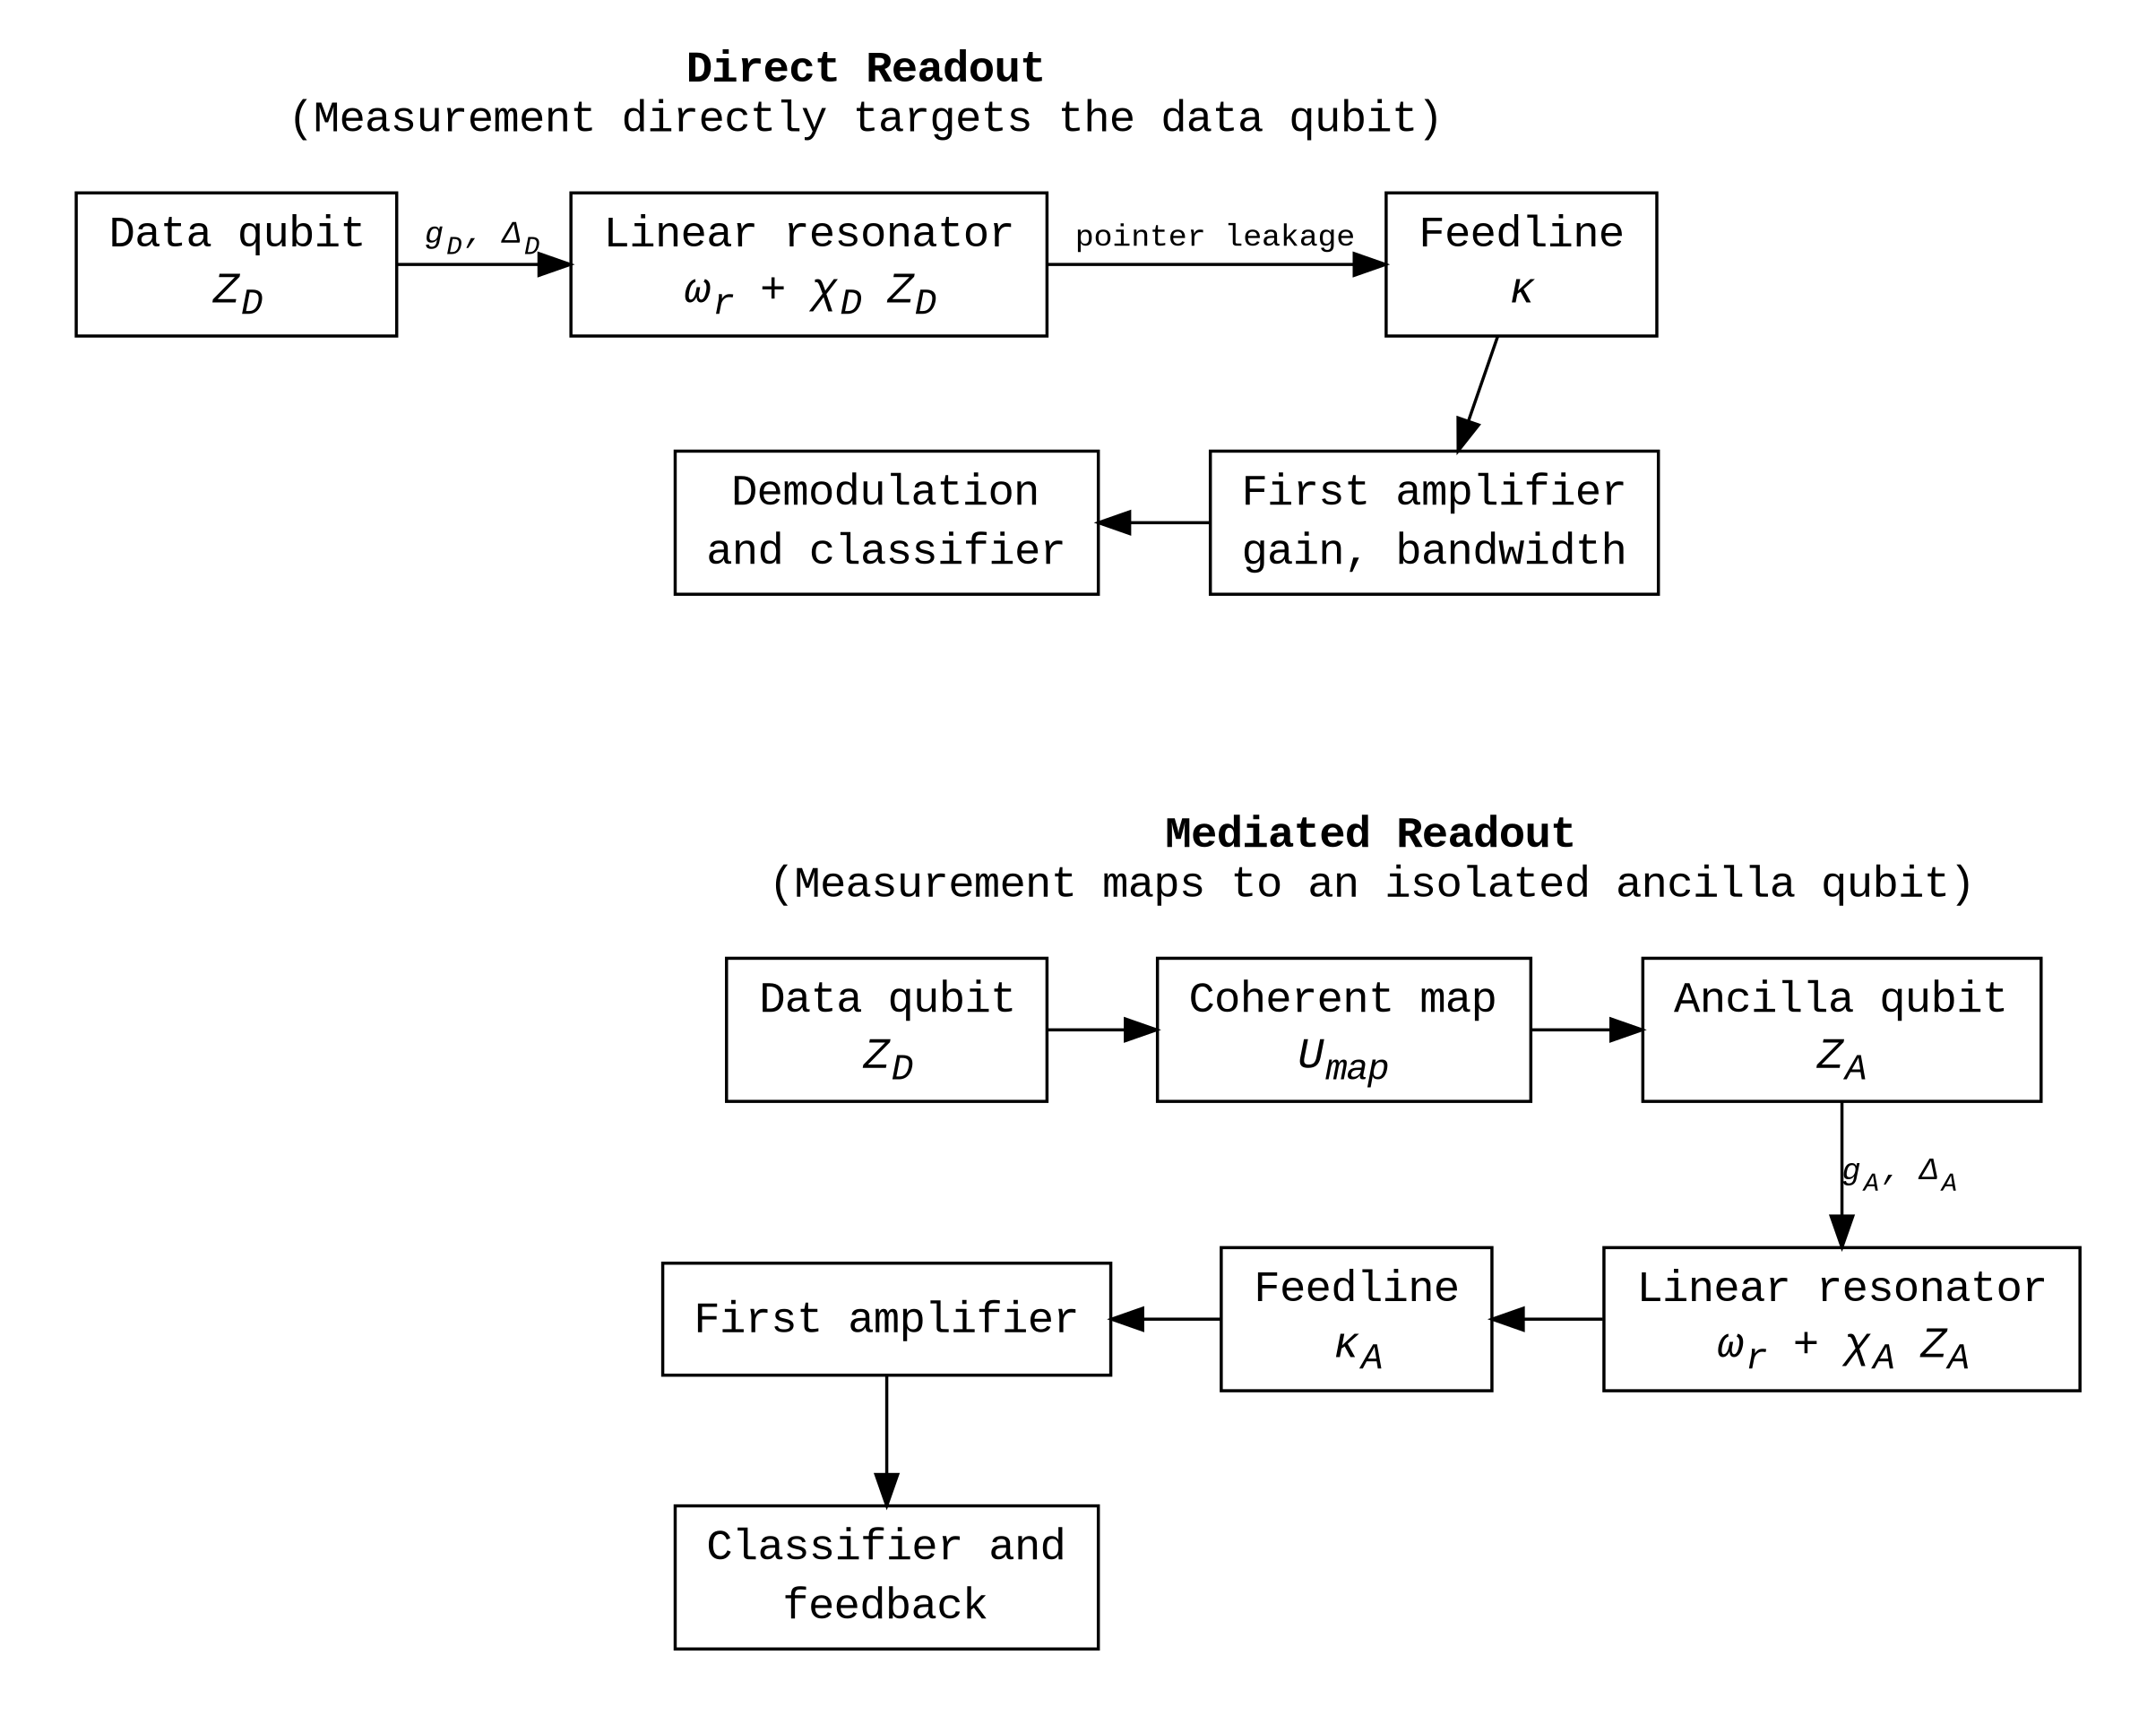

In [16]:
!uv pip install graphviz ipython

"""This script constructs a directed quantum measurement readout graph and renders it as an in-memory downloadable object.

The graph avoids orthogonal edges and maintains an absolute monochrome aesthetic. Control parameters
defined at the module level dictate the precise font, resolution, and spatial characteristics. The script
incorporates a dynamic snaking algorithm constrained by MAX_HORIZONTAL_NODES, which forces long chains
to meander vertically and severely limits the total horizontal width of the final diagram. The output
displays an interactive button permitting users to retrieve the image without touching disk storage.
"""

import base64
import graphviz
from IPython.display import display, Image, HTML


# Control Knobs
GRAPH_DPI = "250"
NODE_FONT = "DejaVu Sans"
NODE_FONT_WEIGHT = "normal"
EDGE_ROUTING = "spline"
NODE_SHAPE = "box"
BACKGROUND_COLOR = "white"
FOREGROUND_COLOR = "black"
RANK_DIRECTION = "TB"
MAX_CHARACTERS_PER_LINE = 27
MAX_HORIZONTAL_NODES = 3  # Control knob: Limits the maximum width of the diagram by forcing a meander
TITLE_TO_GRAPH_MARGIN = "12.0"  # Control knob: Cluster margin float; decreasing this pulls the title text physically closer to the graphic
INTER_GRAPH_MINLEN = "2"     # Control knob: Rank separation integer governing the spacing between the two main charts


def wrap_text(text: str, max_width: int = MAX_CHARACTERS_PER_LINE) -> str:
    """Wraps text to a specified maximum width, bypassing HTML-like labels."""
    if not text:
        return ""
    if text.startswith('<') and text.endswith('>'):
        return text  # HTML labels handle their own spatial formatting natively

    lines = []
    for paragraph in text.split('\n'):
        current_line = ""
        words = paragraph.split()
        for word in words:
            while len(word) > max_width:
                if current_line:
                    lines.append(current_line)
                    current_line = ""
                chunk = word[:max_width - 1] + "-"
                lines.append(chunk)
                word = word[max_width - 1:]

            if current_line:
                if len(current_line) + 1 + len(word) <= max_width:
                    current_line += " " + word
                else:
                    lines.append(current_line)
                    current_line = word
            else:
                current_line = word
        if current_line:
            lines.append(current_line)
    return '\n'.join(lines)


def add_meandering_chain(
    tree: graphviz.Digraph,
    path_id: str,
    path_title: str,
    path_desc: str,
    nodes: list,
    max_width: int
) -> str:
    """Constructs a snaking node sequence that wraps at a specified maximum horizontal width.

    Returns the ID of the final node in the chain to facilitate sequential vertical stacking.
    """
    title_html = f'<<TABLE BORDER="0" CELLBORDER="0" CELLSPACING="0" CELLPADDING="0"><TR><TD ALIGN="CENTER"><B>{path_title}</B></TD></TR><TR><TD ALIGN="CENTER">({path_desc})</TD></TR></TABLE>>'

    # Defining a cluster subgraph anchors the title label geometrically to the bounding box of the enclosed nodes.
    # The color="none" attribute renders the cluster border invisible.
    with tree.subgraph(name=f'cluster_{path_id}') as c:
        c.attr(
            label=title_html,
            fontname=NODE_FONT,
            labelloc='t',
            labeljust='c',
            margin=TITLE_TO_GRAPH_MARGIN,
            color='none'
        )

        chunks = [nodes[i:i + max_width] for i in range(0, len(nodes), max_width)]

        for i, chunk in enumerate(chunks):
            is_ltr = (i % 2 == 0)
            with c.subgraph() as s:
                s.attr(rank='same')

                for curr in chunk:
                    s.node(curr[0], wrap_text(curr[1]))

                if is_ltr:
                    for j in range(len(chunk) - 1):
                        curr = chunk[j]
                        next_node = chunk[j+1]
                        s.edge(curr[0], next_node[0], label=wrap_text(curr[2], 15))
                else:
                    for j in range(len(chunk) - 1, 0, -1):
                        curr = chunk[j]
                        prev = chunk[j-1]
                        s.edge(curr[0], prev[0], label=wrap_text(prev[2], 15), dir='back')

            if i < len(chunks) - 1:
                last_in_chunk = chunk[-1]
                first_in_next = chunks[i+1][0]
                c.edge(last_in_chunk[0], first_in_next[0], label=wrap_text(last_in_chunk[2], 15))

    return nodes[-1][0]


def build_measurement_pathway_tree() -> graphviz.Digraph:
    """Constructs the directed Graphviz object outlining the readout transducer mechanisms."""
    tree = graphviz.Digraph(format='png')

    tree.attr(dpi=GRAPH_DPI, splines=EDGE_ROUTING, bgcolor=BACKGROUND_COLOR, rankdir=RANK_DIRECTION)
    tree.attr('node', shape=NODE_SHAPE, style='solid', color=FOREGROUND_COLOR, fontcolor=FOREGROUND_COLOR, fontname=NODE_FONT)
    tree.attr('edge', color=FOREGROUND_COLOR, arrowhead='normal', fontname=NODE_FONT, fontsize='10')

    direct_nodes = [
        ('D1', '<<TABLE BORDER="0" CELLBORDER="0" CELLSPACING="0"><TR><TD>Data qubit</TD></TR><TR><TD><FONT FACE="Times New Roman"><I>Z<SUB>D</SUB></I></FONT></TD></TR></TABLE>>', '<<FONT FACE="Times New Roman"><I>g<SUB>D</SUB>, Δ<SUB>D</SUB></I></FONT>>'),
        ('D2', '<<TABLE BORDER="0" CELLBORDER="0" CELLSPACING="0"><TR><TD>Linear resonator</TD></TR><TR><TD><FONT FACE="Times New Roman"><I>ω<SUB>r</SUB> + χ<SUB>D</SUB> Z<SUB>D</SUB></I></FONT></TD></TR></TABLE>>', 'pointer leakage'),
        ('D3', '<<TABLE BORDER="0" CELLBORDER="0" CELLSPACING="0"><TR><TD>Feedline</TD></TR><TR><TD><FONT FACE="Times New Roman"><I>κ</I></FONT></TD></TR></TABLE>>', ''),
        ('D4', '<<TABLE BORDER="0" CELLBORDER="0" CELLSPACING="0"><TR><TD>First amplifier</TD></TR><TR><TD>gain, bandwidth</TD></TR></TABLE>>', ''),
        ('D5', '<<TABLE BORDER="0" CELLBORDER="0" CELLSPACING="0"><TR><TD>Demodulation</TD></TR><TR><TD>and classifier</TD></TR></TABLE>>', '')
    ]

    mediated_nodes = [
        ('M1', '<<TABLE BORDER="0" CELLBORDER="0" CELLSPACING="0"><TR><TD>Data qubit</TD></TR><TR><TD><FONT FACE="Times New Roman"><I>Z<SUB>D</SUB></I></FONT></TD></TR></TABLE>>', ''),
        ('M2', '<<TABLE BORDER="0" CELLBORDER="0" CELLSPACING="0"><TR><TD>Coherent map</TD></TR><TR><TD><FONT FACE="Times New Roman"><I>U<SUB>map</SUB></I></FONT></TD></TR></TABLE>>', ''),
        ('M3', '<<TABLE BORDER="0" CELLBORDER="0" CELLSPACING="0"><TR><TD>Ancilla qubit</TD></TR><TR><TD><FONT FACE="Times New Roman"><I>Z<SUB>A</SUB></I></FONT></TD></TR></TABLE>>', '<<FONT FACE="Times New Roman"><I>g<SUB>A</SUB>, Δ<SUB>A</SUB></I></FONT>>'),
        ('M4', '<<TABLE BORDER="0" CELLBORDER="0" CELLSPACING="0"><TR><TD>Linear resonator</TD></TR><TR><TD><FONT FACE="Times New Roman"><I>ω<SUB>r</SUB> + χ<SUB>A</SUB> Z<SUB>A</SUB></I></FONT></TD></TR></TABLE>>', ''),
        ('M5', '<<TABLE BORDER="0" CELLBORDER="0" CELLSPACING="0"><TR><TD>Feedline</TD></TR><TR><TD><FONT FACE="Times New Roman"><I>κ<SUB>A</SUB></I></FONT></TD></TR></TABLE>>', ''),
        ('M6', '<<TABLE BORDER="0" CELLBORDER="0" CELLSPACING="0"><TR><TD>First amplifier</TD></TR></TABLE>>', ''),
        ('M7', '<<TABLE BORDER="0" CELLBORDER="0" CELLSPACING="0"><TR><TD>Classifier and</TD></TR><TR><TD>feedback</TD></TR></TABLE>>', '')
    ]

    last_direct_id = add_meandering_chain(
        tree,
        'Direct',
        'Direct Readout',
        'Measurement directly targets the data qubit',
        direct_nodes,
        MAX_HORIZONTAL_NODES
    )

    # Connecting the final node of the first topological chain directly to the initial node of the second sequence
    tree.edge(last_direct_id, mediated_nodes[0][0], style='invis', minlen=INTER_GRAPH_MINLEN)

    last_mediated_id = add_meandering_chain(
        tree,
        'Mediated',
        'Mediated Readout',
        'Measurement maps to an isolated ancilla qubit',
        mediated_nodes,
        MAX_HORIZONTAL_NODES
    )

    return tree


def display_and_generate_download(tree: graphviz.Digraph) -> None:
    """Renders the graph in memory and constructs a base64 encoded download button."""
    binary_png = tree.pipe(format='png')

    display(Image(data=binary_png))

    encoded_image = base64.b64encode(binary_png).decode('utf-8')

if __name__ == '__main__':
    pathway_tree = build_measurement_pathway_tree()
    display_and_generate_download(pathway_tree)